<center>
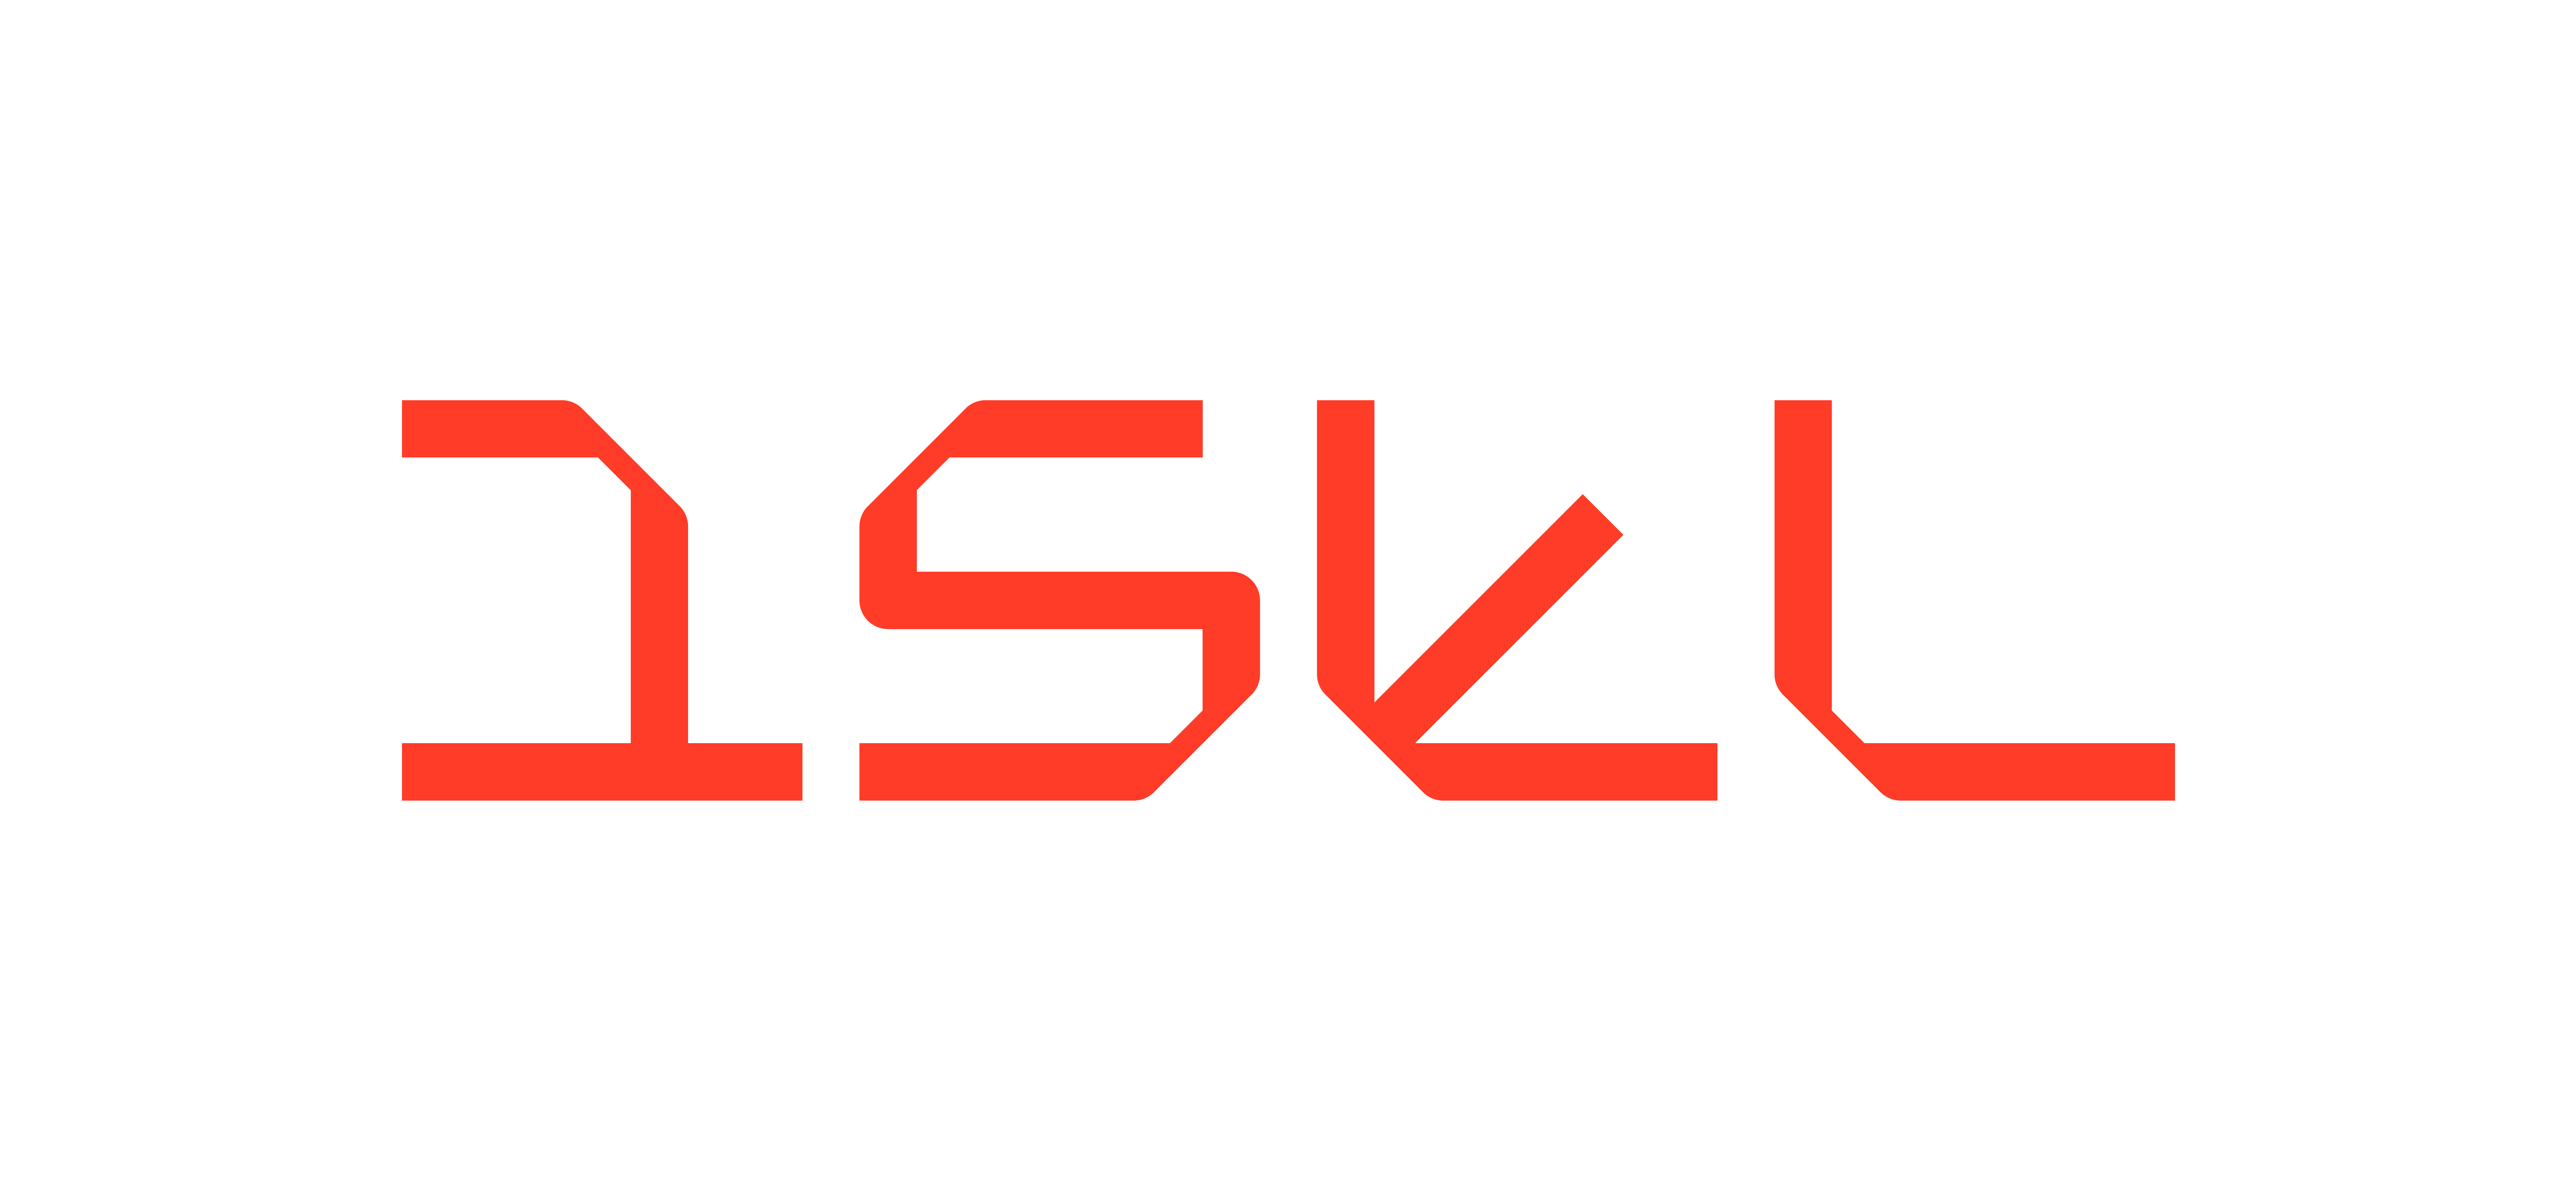
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

### <center>**Introdução**</center> <a class="anchor" id="chapter1"></a>

In [1]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from collections import Counter

In [13]:
# Classe para a bola virtual
class VirtualBall:
    def __init__(self, x, y, radius=30, color=(0, 255, 255)):
        self.x = x
        self.y = y
        self.vx = 0  # velocidade horizontal
        self.vy = 0  # velocidade vertical
        self.radius = radius
        self.color = color
        self.gravity = 0.5  # aceleração da gravidade
        
    def update(self, width, height):
        # Aplicar gravidade
        self.vy += self.gravity
        
        # Atualizar posição
        self.x += self.vx
        self.y += self.vy
        
        # Colisão com bordas
        if self.x - self.radius < 0 or self.x + self.radius > width:
            self.vx *= -0.8  # bounce com perda de energia
            self.x = np.clip(self.x, self.radius, width - self.radius)
            
        if self.y + self.radius > height:
            self.y = height - self.radius
            self.vy *= -0.8
            
    def draw(self, frame):
        cv.circle(frame, (int(self.x), int(self.y)), self.radius, self.color, -1)
        # Sombra para dar profundidade
        cv.circle(frame, (int(self.x), int(self.y)), self.radius, (0, 0, 0), 2)

# Função para detectar pele (mãos) usando HSV
def detect_skin(frame):
    """
    Detecta regiões de pele na imagem usando HSV
    """
    # Converter para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Ranges para cor de pele (ajustáveis)
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    
    # Criar máscara
    mask = cv.inRange(hsv, lower_skin, upper_skin)
    
    # Aplicar operações morfológicas para limpar ruído
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11, 11))
    mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
    mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
    
    # Blur para suavizar
    mask = cv.GaussianBlur(mask, (3, 3), 0)
    
    return mask

# Função para encontrar contornos de mãos
def find_hand_contours(mask, min_area=5000):
    """
    Encontra contornos que provavelmente são mãos
    """
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    # Filtrar por área mínima
    hand_contours = [cnt for cnt in contours if cv.contourArea(cnt) > min_area]
    
    return hand_contours

# Função para verificar colisão com contornos
def check_collision_with_hands(ball, hand_contours):
    """
    Verifica se a bola colidiu com alguma mão
    """
    ball_point = (int(ball.x), int(ball.y))
    
    for contour in hand_contours:
        # Calcular centro do contorno (aproximação da palma)
        M = cv.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            
            # Distância entre bola e centro da mão
            dist = np.sqrt((ball.x - cx)**2 + (ball.y - cy)**2)
            
            # Threshold de colisão
            if dist < ball.radius + 60:
                # Calcular ângulo de impacto
                angle = np.arctan2(ball.y - cy, ball.x - cx)
                
                # Aplicar força
                force = 15
                ball.vx = np.cos(angle) * force
                ball.vy = np.sin(angle) * force - 5
                
                return True, (cx, cy)
    
    return False, None

# Função principal de proof of concept
def proof_of_concept_webcam():
    """
    Teste rápido com webcam usando detecção de cor de pele
    """
    cap = cv.VideoCapture(0)
    
    # Obter dimensões do frame
    ret, frame = cap.read()
    if not ret:
        print("Erro: Não consegui aceder à webcam")
        return
    
    h, w = frame.shape[:2]
    
    # Criar bola no topo
    ball = VirtualBall(w//2, 50)
    
    print("Prima 'q' para sair")
    print("Prima 'r' para reset da bola")
    print("Prima 'm' para ver máscara de detecção")
    
    show_mask = False
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Espelhar imagem para ficar mais intuitivo
        frame = cv.flip(frame, 1)
        h, w = frame.shape[:2]
        
        # Detectar pele
        skin_mask = detect_skin(frame)
        
        # Encontrar contornos de mãos
        hand_contours = find_hand_contours(skin_mask)
        
        # Atualizar física da bola
        ball.update(w, h)
        
        # Verificar colisão
        collision, hand_center = check_collision_with_hands(ball, hand_contours)
        
        # Desenhar contornos das mãos
        cv.drawContours(frame, hand_contours, -1, (0, 255, 0), 2)
        
        # Desenhar centros das mãos
        for contour in hand_contours:
            M = cv.moments(contour)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                cv.circle(frame, (cx, cy), 10, (255, 0, 0), -1)
        
        # Feedback visual de colisão
        if collision:
            cv.putText(frame, "HIT!", (50, 100), 
                     cv.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
        
        # Desenhar bola
        ball.draw(frame)
        
        # Instruções na tela
        cv.putText(frame, "q: sair | r: reset | m: toggle mask", 
                  (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv.putText(frame, f"Maos detectadas: {len(hand_contours)}", 
                  (10, 60), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Mostrar frame
        if show_mask:
            # Mostrar máscara de detecção
            mask_colored = cv.cvtColor(skin_mask, cv.COLOR_GRAY2BGR)
            combined = np.hstack([frame, mask_colored])
            cv.imshow('Proof of Concept - AR', combined)
        else:
            cv.imshow('Proof of Concept - AR', frame)
        
        # Controles
        key = cv.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            # Reset da bola
            ball = VirtualBall(w//2, 50)
        elif key == ord('m'):
            # Toggle máscara
            show_mask = not show_mask
    
    cap.release()
    cv.destroyAllWindows()

# Executar proof of concept
if __name__ == "__main__":
    print("=== PROOF OF CONCEPT - REALIDADE AUMENTADA ===")
    print("(Versão SEM MediaPipe - Detecção por cor)")
    print("Iniciando webcam...")
    proof_of_concept_webcam()

=== PROOF OF CONCEPT - REALIDADE AUMENTADA ===
(Versão SEM MediaPipe - Detecção por cor)
Iniciando webcam...
Prima 'q' para sair
Prima 'r' para reset da bola
Prima 'm' para ver máscara de detecção


In [ ]:
# ==========================================
# MÓDULO 1: SEGMENTAÇÃO (Chromakey/Background)
# ==========================================

class BackgroundSegmenter:
    """
    Classe responsável pela segmentação do fundo.
    Suporta: chromakey (fundo azul/verde) ou fundo constante
    """
    def __init__(self, mode='chromakey', bg_color='green'):
        self.mode = mode
        self.bg_color = bg_color
        self.background_model = None
        
    def segment_chromakey(self, frame):
        """
        Segmentação por chromakey (fundo verde ou azul)
        """
        hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
        
        if self.bg_color == 'green':
            # Range para verde
            lower = np.array([35, 40, 40])
            upper = np.array([85, 255, 255])
        elif self.bg_color == 'blue':
            # Range para azul
            lower = np.array([100, 40, 40])
            upper = np.array([130, 255, 255])
        else:
            raise ValueError("bg_color deve ser 'green' ou 'blue'")
        
        # Criar máscara (1 = fundo, 0 = pessoa)
        mask_bg = cv.inRange(hsv, lower, upper)
        
        # Inverter (1 = pessoa, 0 = fundo)
        mask_person = cv.bitwise_not(mask_bg)
        
        # Limpeza morfológica
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
        mask_person = cv.morphologyEx(mask_person, cv.MORPH_CLOSE, kernel)
        mask_person = cv.morphologyEx(mask_person, cv.MORPH_OPEN, kernel)
        
        return mask_person
    
    def segment_constant_background(self, frame, learning_rate=0.01):
        """
        Segmentação por subtração de fundo (background constante)
        """
        if self.background_model is None:
            # Inicializar modelo de fundo
            self.background_model = frame.astype(np.float32)
            return np.zeros(frame.shape[:2], dtype=np.uint8)
        
        # Atualizar modelo de fundo (média móvel)
        cv.accumulateWeighted(frame, self.background_model, learning_rate)
        background = self.background_model.astype(np.uint8)
        
        # Diferença absoluta
        diff = cv.absdiff(frame, background)
        gray_diff = cv.cvtColor(diff, cv.COLOR_BGR2GRAY)
        
        # Threshold
        _, mask = cv.threshold(gray_diff, 30, 255, cv.THRESH_BINARY)
        
        # Limpeza morfológica
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
        mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
        mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
        
        return mask
    
    def segment(self, frame):
        """
        Segmenta frame baseado no modo escolhido
        """
        if self.mode == 'chromakey':
            return self.segment_chromakey(frame)
        elif self.mode == 'background':
            return self.segment_constant_background(frame)
        else:
            raise ValueError("mode deve ser 'chromakey' ou 'background'")

# ==========================================
# MÓDULO 2: DETECÇÃO DE REGIÕES ATIVAS
# ==========================================

class ActiveRegionDetector:
    """
    Detecta regiões ativas (mãos, pés, cabeça) na máscara segmentada
    """
    def __init__(self, min_area=3000):
        self.min_area = min_area
        
    def detect_hands_feet(self, mask, frame_shape):
        """
        Detecta mãos e pés baseado em:
        - Posição vertical (topo = mãos/cabeça, baixo = pés)
        - Área
        - Forma
        """
        h, w = frame_shape[:2]
        
        # Encontrar contornos
        contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        
        hands = []
        feet = []
        head = None
        
        for cnt in contours:
            area = cv.contourArea(cnt)
            if area < self.min_area:
                continue
            
            # Calcular centro
            M = cv.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            
            # Bounding box
            x, y, bw, bh = cv.boundingRect(cnt)
            
            # Classificar baseado na posição vertical
            relative_y = cy / h
            
            if relative_y < 0.3:
                # Topo da imagem: cabeça ou mãos levantadas
                if area > self.min_area * 3:  # Área grande = cabeça
                    head = {'center': (cx, cy), 'contour': cnt, 'area': area}
                else:
                    hands.append({'center': (cx, cy), 'contour': cnt, 'area': area})
            elif relative_y < 0.7:
                # Meio: provavelmente mãos
                hands.append({'center': (cx, cy), 'contour': cnt, 'area': area})
            else:
                # Baixo: pés
                feet.append({'center': (cx, cy), 'contour': cnt, 'area': area})
        
        return {'hands': hands, 'feet': feet, 'head': head}

# ==========================================
# MÓDULO 3: OBJETOS VIRTUAIS
# ==========================================

class VirtualObject:
    """
    Classe base para objetos virtuais com física simples
    """
    def __init__(self, x, y, vx=0, vy=0):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy
        self.active = True
        
    def update(self, width, height):
        raise NotImplementedError
        
    def draw(self, frame):
        raise NotImplementedError
        
class VirtualBall(VirtualObject):
    """
    Bola virtual com física (gravidade, colisões)
    """
    def __init__(self, x, y, radius=25, color=(0, 255, 255), gravity=0.5):
        super().__init__(x, y)
        self.radius = radius
        self.color = color
        self.gravity = gravity
        self.bounce_damping = 0.75
        
    def update(self, width, height):
        # Aplicar gravidade
        self.vy += self.gravity
        
        # Atualizar posição
        self.x += self.vx
        self.y += self.vy
        
        # Damping (resistência do ar)
        self.vx *= 0.99
        
        # Colisão com bordas laterais
        if self.x - self.radius < 0:
            self.x = self.radius
            self.vx *= -self.bounce_damping
        elif self.x + self.radius > width:
            self.x = width - self.radius
            self.vx *= -self.bounce_damping
        
        # Colisão com chão
        if self.y + self.radius > height:
            self.y = height - self.radius
            self.vy *= -self.bounce_damping
            if abs(self.vy) < 1:  # Parar se velocidade muito baixa
                self.vy = 0
                
        # Colisão com teto
        if self.y - self.radius < 0:
            self.y = self.radius
            self.vy *= -self.bounce_damping
            
    def draw(self, frame):
        # Bola com gradiente para dar profundidade
        cv.circle(frame, (int(self.x), int(self.y)), self.radius, self.color, -1)
        # Highlight para efeito 3D
        highlight_pos = (int(self.x - self.radius//3), int(self.y - self.radius//3))
        cv.circle(frame, highlight_pos, self.radius//4, (255, 255, 255), -1)
        # Contorno
        cv.circle(frame, (int(self.x), int(self.y)), self.radius, (0, 0, 0), 2)

# ==========================================
# MÓDULO 4: DETECÇÃO DE COLISÕES
# ==========================================

class CollisionDetector:
    """
    Detecta e resolve colisões entre objetos virtuais e regiões ativas
    """
    @staticmethod
    def check_ball_region_collision(ball, region, collision_margin=50):
        """
        Verifica colisão entre bola e região ativa (mão/pé)
        """
        cx, cy = region['center']
        dist = np.sqrt((ball.x - cx)**2 + (ball.y - cy)**2)
        
        threshold = ball.radius + collision_margin
        
        if dist < threshold:
            # Calcular vetor normal de colisão
            if dist > 0:
                nx = (ball.x - cx) / dist
                ny = (ball.y - cy) / dist
            else:
                nx, ny = 0, -1
            
            # Aplicar impulso na direção normal
            impulse_strength = 18
            ball.vx = nx * impulse_strength
            ball.vy = ny * impulse_strength - 3  # Pequeno boost para cima
            
            # Afastar bola para evitar colisões múltiplas
            ball.x = cx + nx * threshold
            ball.y = cy + ny * threshold
            
            return True
        
        return False

# ==========================================
# FUNÇÃO PRINCIPAL (Interface do Enunciado)
# ==========================================

def AugmentedReality(video0, ini, fin, mode='chromakey', bg_color='green'):
    """
    Função principal de Realidade Aumentada
    
    Parâmetros:
    -----------
    video0 : str
        Nome do ficheiro AVI com a sequência de vídeo
    ini : int
        Índice da primeira imagem a processar
    fin : int
        Índice da última imagem a processar
    mode : str
        'chromakey' para fundo verde/azul ou 'background' para fundo constante
    bg_color : str
        'green' ou 'blue' (apenas para modo chromakey)
    
    Retorna:
    --------
    video1 : str
        Nome do ficheiro AVI de saída com as interações
    """
    
    video1 = video0.replace('.avi', '_AR.avi')
    
    # Abrir vídeo de entrada
    cap = cv.VideoCapture(video0)
    if not cap.isOpened():
        print(f"Erro: Não foi possível abrir {video0}")
        return None
    
    # Propriedades do vídeo
    fps = int(cap.get(cv.CAP_PROP_FPS))
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    
    # Validar índices
    ini = max(0, ini)
    fin = min(total_frames - 1, fin)
    
    # Configurar writer
    fourcc = cv.VideoWriter_fourcc(*'XVID')
    out = cv.VideoWriter(video1, fourcc, fps, (width, height))
    
    # Inicializar módulos
    segmenter = BackgroundSegmenter(mode=mode, bg_color=bg_color)
    detector = ActiveRegionDetector(min_area=3000)
    collision_detector = CollisionDetector()
    
    # Criar objetos virtuais (exemplo: 3 bolas)
    virtual_objects = [
        VirtualBall(width//4, 50, radius=30, color=(0, 255, 255)),
        VirtualBall(width//2, 100, radius=25, color=(255, 0, 255)),
        VirtualBall(3*width//4, 150, radius=35, color=(255, 255, 0))
    ]
    
    # Posicionar no frame inicial
    cap.set(cv.CAP_PROP_POS_FRAMES, ini)
    
    frame_idx = ini
    print(f"Processando frames {ini} a {fin}...")
    
    while frame_idx <= fin:
        ret, frame = cap.read()
        if not ret:
            break
        
        # 1. SEGMENTAÇÃO
        mask_person = segmenter.segment(frame)
        
        # 2. DETECÇÃO DE REGIÕES ATIVAS
        regions = detector.detect_hands_feet(mask_person, frame.shape)
        
        # 3. ATUALIZAR FÍSICA DOS OBJETOS VIRTUAIS
        for obj in virtual_objects:
            obj.update(width, height)
        
        # 4. DETECÇÃO DE COLISÕES
        for obj in virtual_objects:
            # Verificar colisão com mãos
            for hand in regions['hands']:
                if collision_detector.check_ball_region_collision(obj, hand):
                    # Feedback visual
                    cv.circle(frame, hand['center'], 60, (0, 255, 0), 3)
            
            # Verificar colisão com pés
            for foot in regions['feet']:
                if collision_detector.check_ball_region_collision(obj, foot):
                    cv.circle(frame, foot['center'], 60, (0, 255, 0), 3)
        
        # 5. DESENHAR REGIÕES ATIVAS (visualização)
        for hand in regions['hands']:
            cv.drawContours(frame, [hand['contour']], -1, (0, 255, 0), 2)
            cv.circle(frame, hand['center'], 5, (255, 0, 0), -1)
            cv.putText(frame, "Hand", hand['center'], cv.FONT_HERSHEY_SIMPLEX, 
                      0.5, (255, 255, 255), 1)
        
        for foot in regions['feet']:
            cv.drawContours(frame, [foot['contour']], -1, (0, 0, 255), 2)
            cv.circle(frame, foot['center'], 5, (255, 0, 0), -1)
            cv.putText(frame, "Foot", foot['center'], cv.FONT_HERSHEY_SIMPLEX, 
                      0.5, (255, 255, 255), 1)
        
        # 6. DESENHAR OBJETOS VIRTUAIS
        for obj in virtual_objects:
            obj.draw(frame)
        
        # Info do frame
        cv.putText(frame, f"Frame: {frame_idx}/{fin}", (10, 30),
                  cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Escrever frame processado
        out.write(frame)
        
        frame_idx += 1
        
        # Progresso
        if frame_idx % 30 == 0:
            progress = ((frame_idx - ini) / (fin - ini + 1)) * 100
            print(f"Progresso: {progress:.1f}%")
    
    # Libertar recursos
    cap.release()
    out.release()
    
    print(f"Vídeo processado salvo em: {video1}")
    return video1

# ==========================================
# FUNÇÃO AUXILIAR: Teste em Tempo Real (Webcam)
# ==========================================

def test_realtime(mode='chromakey', bg_color='green'):
    """
    Teste em tempo real com webcam (sugerido no enunciado)
    """
    cap = cv.VideoCapture(0)
    
    ret, frame = cap.read()
    if not ret:
        print("Erro ao aceder à webcam")
        return
    
    h, w = frame.shape[:2]
    
    # Inicializar módulos
    segmenter = BackgroundSegmenter(mode=mode, bg_color=bg_color)
    detector = ActiveRegionDetector()
    collision_detector = CollisionDetector()
    
    # Objetos virtuais
    balls = [VirtualBall(w//2, 50, radius=30, color=(0, 255, 255))]
    
    print("Controles: 'q' sair | 'r' reset | 'a' adicionar bola | 'm' toggle mask")
    show_mask = False
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame = cv.flip(frame, 1)
        h, w = frame.shape[:2]
        
        # Processar
        mask = segmenter.segment(frame)
        regions = detector.detect_hands_feet(mask, frame.shape)
        
        # Atualizar física
        for ball in balls:
            ball.update(w, h)
        
        # Colisões
        for ball in balls:
            for hand in regions['hands']:
                if collision_detector.check_ball_region_collision(ball, hand):
                    cv.circle(frame, hand['center'], 60, (0, 255, 0), 3)
        
        # Desenhar
        for hand in regions['hands']:
            cv.drawContours(frame, [hand['contour']], -1, (0, 255, 0), 2)
        
        for ball in balls:
            ball.draw(frame)
        
        cv.putText(frame, f"Bolas: {len(balls)} | Maos: {len(regions['hands'])}", 
                  (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        if show_mask:
            mask_vis = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
            display = np.hstack([frame, mask_vis])
            cv.imshow('AR Real-Time', display)
        else:
            cv.imshow('AR Real-Time', frame)
        
        key = cv.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            balls = [VirtualBall(w//2, 50)]
        elif key == ord('a'):
            balls.append(VirtualBall(np.random.randint(100, w-100), 50,
                                    color=tuple(np.random.randint(0, 255, 3).tolist())))
        elif key == ord('m'):
            show_mask = not show_mask
    
    cap.release()
    cv.destroyAllWindows()

# ==========================================
# EXEMPLO DE USO
# ==========================================

if __name__ == "__main__":
    # Teste em tempo real (webcam)
    print("Iniciando teste em tempo real...")
    print("ATENÇÃO: Para chromakey funcionar, precisa de fundo verde/azul!")
    print("Caso contrário, use mode='background'")
    
    test_realtime(mode='background')  # Usar 'chromakey' se tiver fundo verde/azul
    
    # Processar vídeo (descomente quando tiver vídeo)
    # video_saida = AugmentedReality('video_entrada.avi', 0, 300, mode='chromakey', bg_color='green')

Frame capturado: (480, 640, 3)


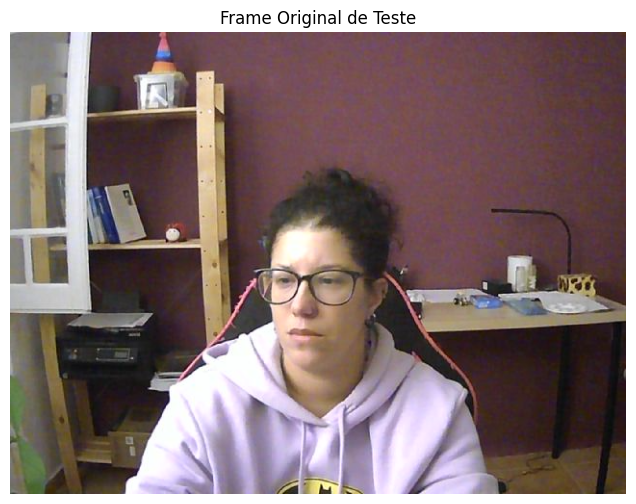

In [ ]:
# Capturar um frame da webcam para experiência

cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

🎯 SEGMENTAÇÃO AVANÇADA - Métodos Profissionais

📊 TESTE 1: GrabCut (Segmentação Iterativa)
Algoritmo usado por muitas apps antes de ML


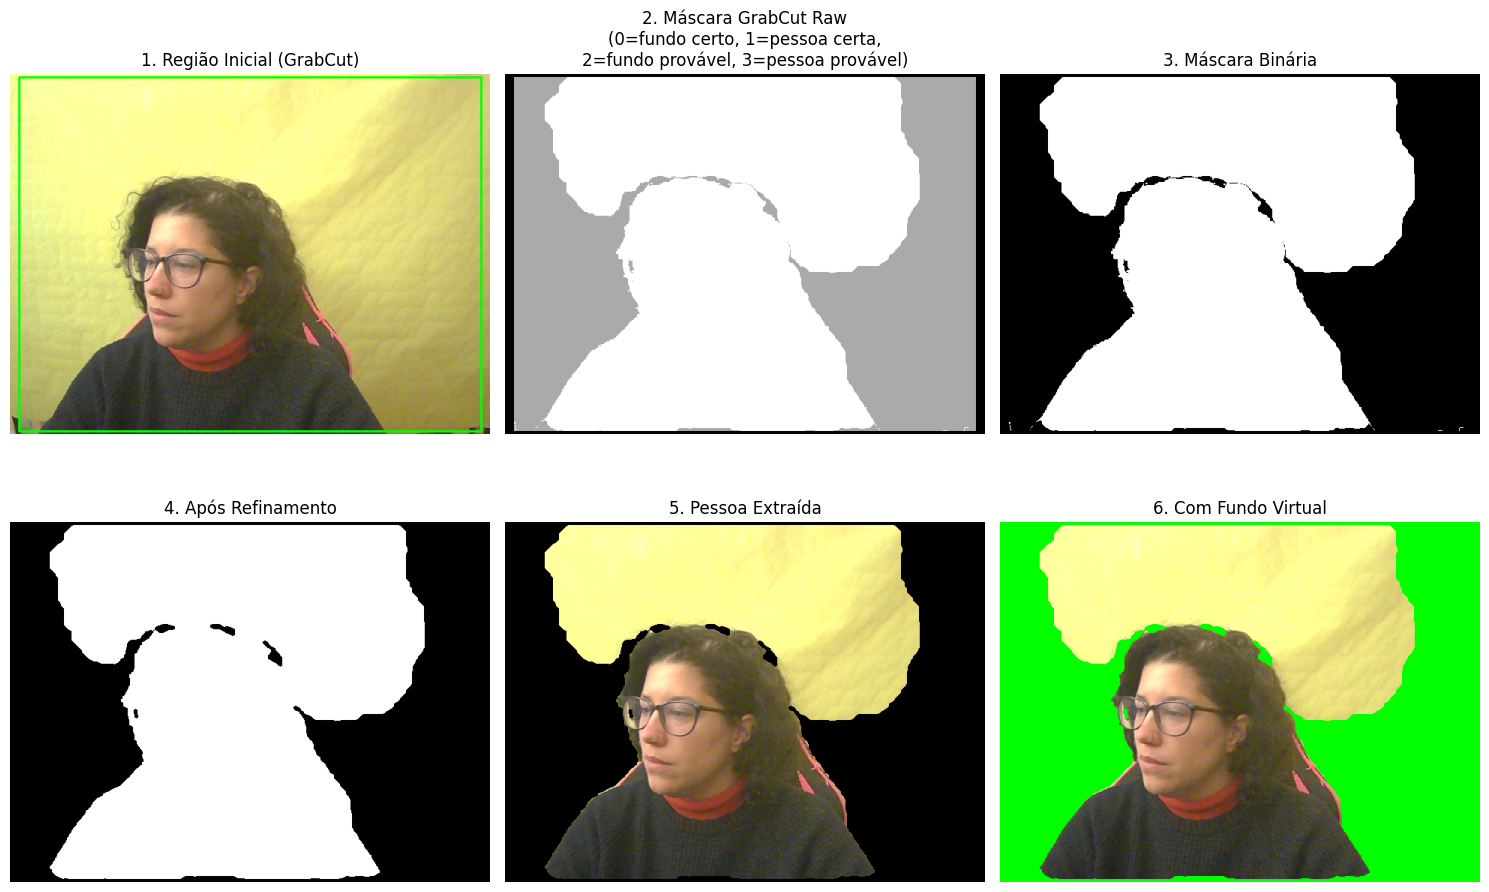


💡 VANTAGENS DO GRABCUT:
  ✅ Não precisa de fundo específico
  ✅ Contornos mais precisos que chromakey
  ✅ Funciona bem com boa iluminação
  ❌ Mais lento (iterativo)
  ❌ Pode precisar de ajuste manual do rect inicial

📊 TESTE 2: Ajuste Interativo de Ranges
Use os sliders para encontrar os melhores valores para SEU fundo!
(Funciona para QUALQUER cor de fundo, não só verde/azul)

🎯 RECOMENDAÇÃO FINAL:

Para MELHOR QUALIDADE (tipo Zoom):
  1. Use MÉTODO HÍBRIDO (background + GrabCut)
  2. Capture frame vazio do fundo
  3. Aplique GrabCut para refinar contornos

Para VELOCIDADE:
  1. Use Chromakey simples (se tiver fundo colorido)
  2. Ajuste ranges com ferramenta interativa

Para SIMPLICIDADE:
  1. Use Background Subtraction básico
  2. Bom compromisso velocidade/qualidade



In [13]:
# SEGMENTAÇÃO AVANÇADA - Parte 2
# Ajuste Interativo + Método "Zoom-like"

from matplotlib.widgets import Slider

# ==========================================
# PARTE 1: Ferramenta de Ajuste Interativo de Ranges
# ==========================================

def interactive_color_range_tuner(frame):
    """
    Interface interativa para ajustar ranges de cor HSV
    Permite encontrar os melhores valores para qualquer cor de fundo
    """
    
    # Converter para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Valores iniciais (verde)
    h_min, s_min, v_min = 35, 40, 40
    h_max, s_max, v_max = 85, 255, 255
    
    # Setup da figura
    fig = plt.figure(figsize=(16, 10))
    
    # Layout: original, HSV, máscara
    ax_original = plt.subplot(2, 3, 1)
    ax_hsv = plt.subplot(2, 3, 2)
    ax_mask = plt.subplot(2, 3, 3)
    ax_result = plt.subplot(2, 3, 4)
    ax_histogram = plt.subplot(2, 3, 5)
    ax_final = plt.subplot(2, 3, 6)
    
    # Imagens iniciais
    img_original = ax_original.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
    ax_original.set_title("Frame Original")
    ax_original.axis('off')
    
    img_hsv = ax_hsv.imshow(cv.cvtColor(hsv, cv.COLOR_HSV2RGB))
    ax_hsv.set_title("HSV")
    ax_hsv.axis('off')
    
    # Calcular máscara inicial
    lower = np.array([h_min, s_min, v_min])
    upper = np.array([h_max, s_max, v_max])
    mask = cv.inRange(hsv, lower, upper)
    
    img_mask = ax_mask.imshow(mask, cmap='gray')
    ax_mask.set_title("Máscara (Fundo)")
    ax_mask.axis('off')
    
    # Resultado com fundo verde
    result = frame.copy()
    result[mask > 0] = [0, 255, 0]
    img_result = ax_result.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    ax_result.set_title("Fundo Destacado")
    ax_result.axis('off')
    
    # Histograma HSV
    h_hist = cv.calcHist([hsv], [0], None, [180], [0, 180])
    ax_histogram.plot(h_hist, color='red', label='Hue')
    ax_histogram.set_title("Histograma H")
    ax_histogram.set_xlim([0, 180])
    ax_histogram.legend()
    
    # Máscara invertida (pessoa)
    mask_inv = cv.bitwise_not(mask)
    img_final = ax_final.imshow(mask_inv, cmap='gray')
    ax_final.set_title("Máscara Final (Pessoa)")
    ax_final.axis('off')
    
    # Criar sliders
    plt.subplots_adjust(bottom=0.35)
    
    ax_h_min = plt.axes([0.1, 0.25, 0.8, 0.02])
    ax_h_max = plt.axes([0.1, 0.22, 0.8, 0.02])
    ax_s_min = plt.axes([0.1, 0.19, 0.8, 0.02])
    ax_s_max = plt.axes([0.1, 0.16, 0.8, 0.02])
    ax_v_min = plt.axes([0.1, 0.13, 0.8, 0.02])
    ax_v_max = plt.axes([0.1, 0.10, 0.8, 0.02])
    
    slider_h_min = Slider(ax_h_min, 'H min', 0, 179, valinit=h_min, valstep=1)
    slider_h_max = Slider(ax_h_max, 'H max', 0, 179, valinit=h_max, valstep=1)
    slider_s_min = Slider(ax_s_min, 'S min', 0, 255, valinit=s_min, valstep=1)
    slider_s_max = Slider(ax_s_max, 'S max', 0, 255, valinit=s_max, valstep=1)
    slider_v_min = Slider(ax_v_min, 'V min', 0, 255, valinit=v_min, valstep=1)
    slider_v_max = Slider(ax_v_max, 'V max', 0, 255, valinit=v_max, valstep=1)
    
    def update(val):
        lower = np.array([slider_h_min.val, slider_s_min.val, slider_v_min.val])
        upper = np.array([slider_h_max.val, slider_s_max.val, slider_v_max.val])
        
        mask = cv.inRange(hsv, lower, upper)
        mask_inv = cv.bitwise_not(mask)
        
        result = frame.copy()
        result[mask > 0] = [0, 255, 0]
        
        img_mask.set_data(mask)
        img_result.set_data(cv.cvtColor(result, cv.COLOR_BGR2RGB))
        img_final.set_data(mask_inv)
        
        fig.canvas.draw_idle()
        
        # Print valores (para copiar depois)
        print(f"\rRanges: H=[{int(slider_h_min.val)}, {int(slider_h_max.val)}], "
              f"S=[{int(slider_s_min.val)}, {int(slider_s_max.val)}], "
              f"V=[{int(slider_v_min.val)}, {int(slider_v_max.val)}]", end='')
    
    slider_h_min.on_changed(update)
    slider_h_max.on_changed(update)
    slider_s_min.on_changed(update)
    slider_s_max.on_changed(update)
    slider_v_min.on_changed(update)
    slider_v_max.on_changed(update)
    
    plt.show()
    
    # Retornar valores finais
    return {
        'h_min': int(slider_h_min.val),
        'h_max': int(slider_h_max.val),
        's_min': int(slider_s_min.val),
        's_max': int(slider_s_max.val),
        'v_min': int(slider_v_min.val),
        'v_max': int(slider_v_max.val)
    }

# ==========================================
# PARTE 2: Método "Zoom-like" - GrabCut + Refinamento
# ==========================================

def segment_grabcut(frame, rect=None, iterations=5, show_process=True):
    """
    Segmentação usando GrabCut (algoritmo iterativo baseado em Graph Cuts)
    Similar ao que apps modernas usam como baseline antes de ML
    
    Parâmetros:
    - frame: imagem BGR
    - rect: (x, y, w, h) região inicial onde está a pessoa (None = automático)
    - iterations: número de iterações do GrabCut
    """
    
    mask = np.zeros(frame.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    
    # Se não forneceu rect, usar região central (assumir pessoa no centro)
    if rect is None:
        h, w = frame.shape[:2]
        margin_x = int(w * 0.02)  # 2% margem de cada lado
        margin_y = int(h * 0.01)  # 1% margem topo/fundo
        rect = (margin_x, margin_y, w - 2*margin_x, h - 2*margin_y)
    
    # Aplicar GrabCut
    cv.grabCut(frame, mask, rect, bgd_model, fgd_model, iterations, cv.GC_INIT_WITH_RECT)
    
    # Criar máscara binária (0 e 2 = fundo, 1 e 3 = pessoa)
    mask_binary = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    
    # Refinamento adicional (morfologia)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    mask_refined = cv.morphologyEx(mask_binary * 255, cv.MORPH_CLOSE, kernel)
    mask_refined = cv.morphologyEx(mask_refined, cv.MORPH_OPEN, kernel)
    
    if show_process:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Original com retângulo
        frame_rect = frame.copy()
        x, y, w, h = rect
        cv.rectangle(frame_rect, (x, y), (x+w, y+h), (0, 255, 0), 2)
        axes[0, 0].imshow(cv.cvtColor(frame_rect, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("1. Região Inicial (GrabCut)")
        axes[0, 0].axis('off')
        
        # Máscara GrabCut raw
        axes[0, 1].imshow(mask, cmap='gray')
        axes[0, 1].set_title("2. Máscara GrabCut Raw\n(0=fundo certo, 1=pessoa certa,\n2=fundo provável, 3=pessoa provável)")
        axes[0, 1].axis('off')
        
        # Máscara binária
        axes[0, 2].imshow(mask_binary, cmap='gray')
        axes[0, 2].set_title("3. Máscara Binária")
        axes[0, 2].axis('off')
        
        # Após refinamento
        axes[1, 0].imshow(mask_refined, cmap='gray')
        axes[1, 0].set_title("4. Após Refinamento")
        axes[1, 0].axis('off')
        
        # Resultado segmentado
        result = frame.copy()
        result[mask_refined == 0] = [0, 0, 0]
        axes[1, 1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
        axes[1, 1].set_title("5. Pessoa Extraída")
        axes[1, 1].axis('off')
        
        # Com fundo substituído
        result_bg = frame.copy()
        result_bg[mask_refined == 0] = [0, 255, 0]
        axes[1, 2].imshow(cv.cvtColor(result_bg, cv.COLOR_BGR2RGB))
        axes[1, 2].set_title("6. Com Fundo Virtual")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_refined

# ==========================================
# PARTE 3: Método Híbrido (Background + GrabCut)
# ==========================================

def segment_hybrid(frame, background=None, use_grabcut=True, show_process=True):
    """
    Método híbrido: combina background subtraction com GrabCut
    Aproxima-se mais dos resultados tipo Zoom
    """
    
    if background is None:
        print("⚠️ Precisa de frame de fundo para método híbrido")
        return None
    
    # Passo 1: Background Subtraction (grosseiro)
    diff = cv.absdiff(frame, background)
    gray_diff = cv.cvtColor(diff, cv.COLOR_BGR2GRAY)
    _, mask_rough = cv.threshold(gray_diff, 25, 255, cv.THRESH_BINARY)
    
    # Morfologia para limpar
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
    mask_rough = cv.morphologyEx(mask_rough, cv.MORPH_CLOSE, kernel)
    mask_rough = cv.morphologyEx(mask_rough, cv.MORPH_OPEN, kernel)
    
    if not use_grabcut:
        return mask_rough
    
    # Passo 2: Usar máscara rough para guiar GrabCut
    # Encontrar bounding box da pessoa
    contours, _ = cv.findContours(mask_rough, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        print("⚠️ Nenhuma pessoa detectada")
        return mask_rough
    
    # Maior contorno = pessoa
    largest_contour = max(contours, key=cv.contourArea)
    x, y, w, h = cv.boundingRect(largest_contour)
    
    # Expandir um pouco o rect
    margin = 20
    x = max(0, x)
    y = max(0, y)
    w = frame.shape[1]
    h = frame.shape[0]
    
    # Aplicar GrabCut apenas na região relevante
    mask_final = segment_grabcut(frame, rect=(0, 0, w, h), 
                                  iterations=3, show_process=False)
    
    if show_process:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("1. Frame Atual")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(mask_rough, cmap='gray')
        axes[0, 1].set_title("2. Background Subtraction")
        axes[0, 1].axis('off')
        
        axes[1, 0].imshow(mask_final, cmap='gray')
        axes[1, 0].set_title("3. GrabCut Refinado")
        axes[1, 0].axis('off')
        
        result = frame.copy()
        result[mask_final == 0] = [0, 255, 0]
        axes[1, 1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
        axes[1, 1].set_title("4. Resultado Final")
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_final

# ==========================================
# PARTE 4: Testes e Comparações
# ==========================================

print("="*60)
print("🎯 SEGMENTAÇÃO AVANÇADA - Métodos Profissionais")
print("="*60)

# Capturar frame de teste
cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
if ret:
    frame_test = cv.flip(frame_test, 1)

print("\n📊 TESTE 1: GrabCut (Segmentação Iterativa)")
print("Algoritmo usado por muitas apps antes de ML")
if ret:
    mask_grabcut = segment_grabcut(frame_test, rect=None, iterations=5, show_process=True)

print("\n" + "="*60)
print("💡 VANTAGENS DO GRABCUT:")
print("  ✅ Não precisa de fundo específico")
print("  ✅ Contornos mais precisos que chromakey")
print("  ✅ Funciona bem com boa iluminação")
print("  ❌ Mais lento (iterativo)")
print("  ❌ Pode precisar de ajuste manual do rect inicial")
print("="*60)

print("\n📊 TESTE 2: Ajuste Interativo de Ranges")
print("Use os sliders para encontrar os melhores valores para SEU fundo!")
print("(Funciona para QUALQUER cor de fundo, não só verde/azul)")

# Descomente para usar ferramenta interativa:
# ranges = interactive_color_range_tuner(frame_test)
# print(f"\n✅ Ranges encontrados: {ranges}")

cap.release()

print("\n" + "="*60)
print("🎯 RECOMENDAÇÃO FINAL:")
print("="*60)
print("""
Para MELHOR QUALIDADE (tipo Zoom):
  1. Use MÉTODO HÍBRIDO (background + GrabCut)
  2. Capture frame vazio do fundo
  3. Aplique GrabCut para refinar contornos
  
Para VELOCIDADE:
  1. Use Chromakey simples (se tiver fundo colorido)
  2. Ajuste ranges com ferramenta interativa
  
Para SIMPLICIDADE:
  1. Use Background Subtraction básico
  2. Bom compromisso velocidade/qualidade
""")

In [36]:
frame_test.shape[1]

640

In [14]:
# Análise de Histograma
# Identificar cor dominante do fundo

def analyze_frame_colors(frame, n_clusters=5, show_analysis=True):
    """
    Analisa as cores predominantes no frame
    
    Retorna:
    - Cores dominantes (BGR)
    - Percentagem de cada cor
    - Histogramas HSV
    """
    
    # Redimensionar para acelerar (opcional)
    small_frame = cv.resize(frame, (frame.shape[1]//4, frame.shape[0]//4))
    
    # Converter para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Calcular histogramas de cada canal
    h_hist = cv.calcHist([hsv], [0], None, [180], [0, 180])
    s_hist = cv.calcHist([hsv], [1], None, [256], [0, 256])
    v_hist = cv.calcHist([hsv], [2], None, [256], [0, 256])
    
    # Encontrar picos nos histogramas
    h_peaks = np.argsort(h_hist.flatten())[-3:]  # Top 3 Hues
    s_peaks = np.argsort(s_hist.flatten())[-3:]  # Top 3 Saturations
    
    # Análise de cor dominante usando regiões da imagem
    # Dividir frame em 9 regiões (3x3 grid)
    h, w = frame.shape[:2]
    regions = {
        'top_left': frame[0:h//3, 0:w//3],
        'top_center': frame[0:h//3, w//3:2*w//3],
        'top_right': frame[0:h//3, 2*w//3:w],
        'center_left': frame[h//3:2*h//3, 0:w//3],
        'center': frame[h//3:2*h//3, w//3:2*w//3],
        'center_right': frame[h//3:2*h//3, 2*w//3:w],
        'bottom_left': frame[2*h//3:h, 0:w//3],
        'bottom_center': frame[2*h//3:h, w//3:2*w//3],
        'bottom_right': frame[2*h//3:h, 2*w//3:w]
    }
    
    # Calcular cor média de cada região
    region_colors = {}
    for name, region in regions.items():
        mean_color = region.mean(axis=0).mean(axis=0)  # BGR
        region_colors[name] = mean_color
    
    # Identificar regiões de "fundo" (assumir que bordas = fundo)
    background_regions = ['top_left', 'top_center', 'top_right', 
                          'center_left', 'center_right',
                          'bottom_left', 'bottom_center', 'bottom_right']
    
    background_colors = [region_colors[r] for r in background_regions]
    dominant_bg_color = np.median(background_colors, axis=0)
    
    if show_analysis:
        fig = plt.figure(figsize=(16, 10))
        
        # Grid de layout
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
        
        # Frame original
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        ax1.set_title("Frame Original", fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Grid de regiões
        ax2 = fig.add_subplot(gs[0, 2:])
        grid_vis = frame.copy()
        cv.line(grid_vis, (w//3, 0), (w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (2*w//3, 0), (2*w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (0, h//3), (w, h//3), (255, 255, 255), 2)
        cv.line(grid_vis, (0, 2*h//3), (w, 2*h//3), (255, 255, 255), 2)
        ax2.imshow(cv.cvtColor(grid_vis, cv.COLOR_BGR2RGB))
        ax2.set_title("Divisão em Regiões", fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        # Histograma H
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(h_hist, color='red', linewidth=2)
        ax3.set_title("Histograma Hue")
        ax3.set_xlabel("Hue (0-179)")
        ax3.set_xlim([0, 180])
        ax3.grid(True, alpha=0.3)
        # Marcar picos
        for peak in h_peaks:
            ax3.axvline(x=peak, color='green', linestyle='--', alpha=0.7)
        
        # Histograma S
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(s_hist, color='green', linewidth=2)
        ax4.set_title("Histograma Saturation")
        ax4.set_xlabel("Saturation (0-255)")
        ax4.set_xlim([0, 256])
        ax4.grid(True, alpha=0.3)
        
        # Histograma V
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.plot(v_hist, color='blue', linewidth=2)
        ax5.set_title("Histograma Value")
        ax5.set_xlabel("Value (0-255)")
        ax5.set_xlim([0, 256])
        ax5.grid(True, alpha=0.3)
        
        # Cor dominante de fundo
        ax6 = fig.add_subplot(gs[1, 3])
        color_square = np.ones((100, 100, 3), dtype=np.uint8)
        color_square[:, :] = dominant_bg_color.astype(np.uint8)
        ax6.imshow(cv.cvtColor(color_square, cv.COLOR_BGR2RGB))
        ax6.set_title(f"Cor Dominante Fundo\nBGR: {dominant_bg_color.astype(int)}")
        ax6.axis('off')
        
        # Mapa de cores das regiões
        ax7 = fig.add_subplot(gs[2, :])
        region_vis = np.zeros((100, 900, 3), dtype=np.uint8)
        for i, (name, color) in enumerate(region_colors.items()):
            region_vis[:, i*100:(i+1)*100] = color.astype(np.uint8)
            
        ax7.imshow(cv.cvtColor(region_vis, cv.COLOR_BGR2RGB))
        ax7.set_title("Cores Médias de Cada Região")
        ax7.set_xticks(np.arange(50, 900, 100))
        ax7.set_xticklabels(list(region_colors.keys()), rotation=45, ha='right')
        ax7.set_yticks([])
        
        plt.show()
    
    return {
        'dominant_bg_color_bgr': dominant_bg_color,
        'h_peaks': h_peaks,
        's_peaks': s_peaks,
        'h_hist': h_hist,
        's_hist': s_hist,
        'v_hist': v_hist,
        'region_colors': region_colors
    }

In [15]:
# Segmentação Baseada em Histograma

def segment_by_background_color(frame, bg_color_bgr, tolerance=30, show_steps=True):
    """
    Segmenta removendo pixels similares à cor de fundo dominante
    
    Parâmetros:
    - bg_color_bgr: cor do fundo em BGR (numpy array)
    - tolerance: tolerância de diferença (0-255)
    """
    
    # Converter cor de fundo para HSV
    bg_color_hsv = cv.cvtColor(np.uint8([[bg_color_bgr]]), cv.COLOR_BGR2HSV)[0][0]
    
    # Converter frame para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Criar ranges baseados na cor de fundo ± tolerância
    h_min = int(max(0, bg_color_hsv[0] - tolerance//2))
    h_max = int(min(179, bg_color_hsv[0] + tolerance//2))
    s_min = int(max(0, bg_color_hsv[1] - tolerance))
    s_max = int(min(255, int(bg_color_hsv[1]) + tolerance))
    v_min = int(max(0, bg_color_hsv[2] - tolerance))
    v_max = int(min(255, bg_color_hsv[2] + tolerance))
    
    lower = np.array([h_min, s_min, v_min], dtype=np.uint8)
    upper = np.array([h_max, s_max, v_max], dtype=np.uint8)
    
    # Máscara do fundo
    mask_bg = cv.inRange(hsv, lower, upper)
    
    # Inverter (queremos pessoa)
    mask_person = cv.bitwise_not(mask_bg)
    
    # Limpeza morfológica
    kernel_size = (2,2)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_person, cv.MORPH_CLOSE, kernel, iterations=2)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=1)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Mostrar cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color_bgr.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title(f"Cor Fundo Detectada\nHSV: {bg_color_hsv}")
        axes[0, 1].axis('off')
        
        # Ranges usados
        info_text = f"Ranges HSV:\nH: [{h_min}, {h_max}]\nS: [{s_min}, {s_max}]\nV: [{v_min}, {v_max}]"
        axes[0, 2].text(0.1, 0.5, info_text, fontsize=12, family='monospace',
                       verticalalignment='center')
        axes[0, 2].set_title("Parâmetros")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_bg, cmap='gray')
        axes[1, 0].set_title("Máscara Fundo")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_person, cmap='gray')
        axes[1, 1].set_title("Máscara Invertida")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_clean, cmap='gray')
        axes[1, 2].set_title("Após Morfologia")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_clean

In [19]:
# Segmentação por Detecção de Pele
# (Mantém tons de pele, remove resto)

def segment_by_skin_detection(frame, show_steps=True):
    """
    Abordagem inversa: detecta e mantém pixels de pele
    Remove tudo o que NÃO é pele
    """
    
    # Converter para YCrCb (melhor para detecção de pele)
    ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
    
    # Ranges de tons de pele em YCrCb (mais robusto que HSV)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    
    mask_skin_ycrcb = cv.inRange(ycrcb, lower_skin, upper_skin)
    
    # Também usar HSV como backup
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    lower_skin_hsv = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin_hsv = np.array([20, 255, 255], dtype=np.uint8)
    
    mask_skin_hsv = cv.inRange(hsv, lower_skin_hsv, upper_skin_hsv)
    
    # Combinar ambas as máscaras (OR lógico)
#    mask_skin = cv.bitwise_or(mask_skin_ycrcb, mask_skin_hsv)
    mask_skin = cv.bitwise_and(mask_skin_ycrcb, mask_skin_hsv)

    
    # Limpeza morfológica agressiva
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, kernel, iterations=3)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=2)
    
    # Dilatar para capturar corpo completo (não só pele exposta)
    kernel_dilate = cv.getStructuringElement(cv.MORPH_ELLIPSE, (21, 21))
    mask_dilated = cv.dilate(mask_clean, kernel_dilate, iterations=3)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(mask_skin_ycrcb, cmap='gray')
        axes[0, 1].set_title("Detecção Pele (YCrCb)")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_skin_hsv, cmap='gray')
        axes[0, 2].set_title("Detecção Pele (HSV)")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Máscaras Combinadas")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_clean, cmap='gray')
        axes[1, 1].set_title("Após Morfologia")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_dilated, cmap='gray')
        axes[1, 2].set_title("Dilatada (corpo completo)")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_dilated

In [17]:
# EXPERIÊNCIA 4: Método Híbrido Inteligente

def segment_hybrid_intelligent(frame, show_steps=True):
    """
    Combina análise de histograma + detecção de pele
    Mais robusto!
    """
    
    # Passo 1: Analisar cores do frame
    analysis = analyze_frame_colors(frame, show_analysis=False)
    bg_color = analysis['dominant_bg_color_bgr']
    
    # Passo 2: Segmentar por cor de fundo
    mask_bg_removal = segment_by_background_color(frame, bg_color, 
                                                   tolerance=50, show_steps=False)
    
    # Passo 3: Detectar pele
    mask_skin = segment_by_skin_detection(frame, show_steps=False)
    
    # Passo 4: Combinar (união)
    mask_combined = cv.bitwise_or(mask_bg_removal, mask_skin)
    
    # Passo 5: Limpeza final
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_final = cv.morphologyEx(mask_combined, cv.MORPH_CLOSE, kernel, iterations=2)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title("Fundo Auto-detectado")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_bg_removal, cmap='gray')
        axes[0, 2].set_title("Remoção de Fundo")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Detecção de Pele")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_combined, cmap='gray')
        axes[1, 1].set_title("Máscaras Combinadas")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_final, cmap='gray')
        axes[1, 2].set_title("Resultado Final")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_final

🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO
✅ Frame capturado

📊 EXPERIÊNCIA 1: Análise de Cores do Frame
------------------------------------------------------------


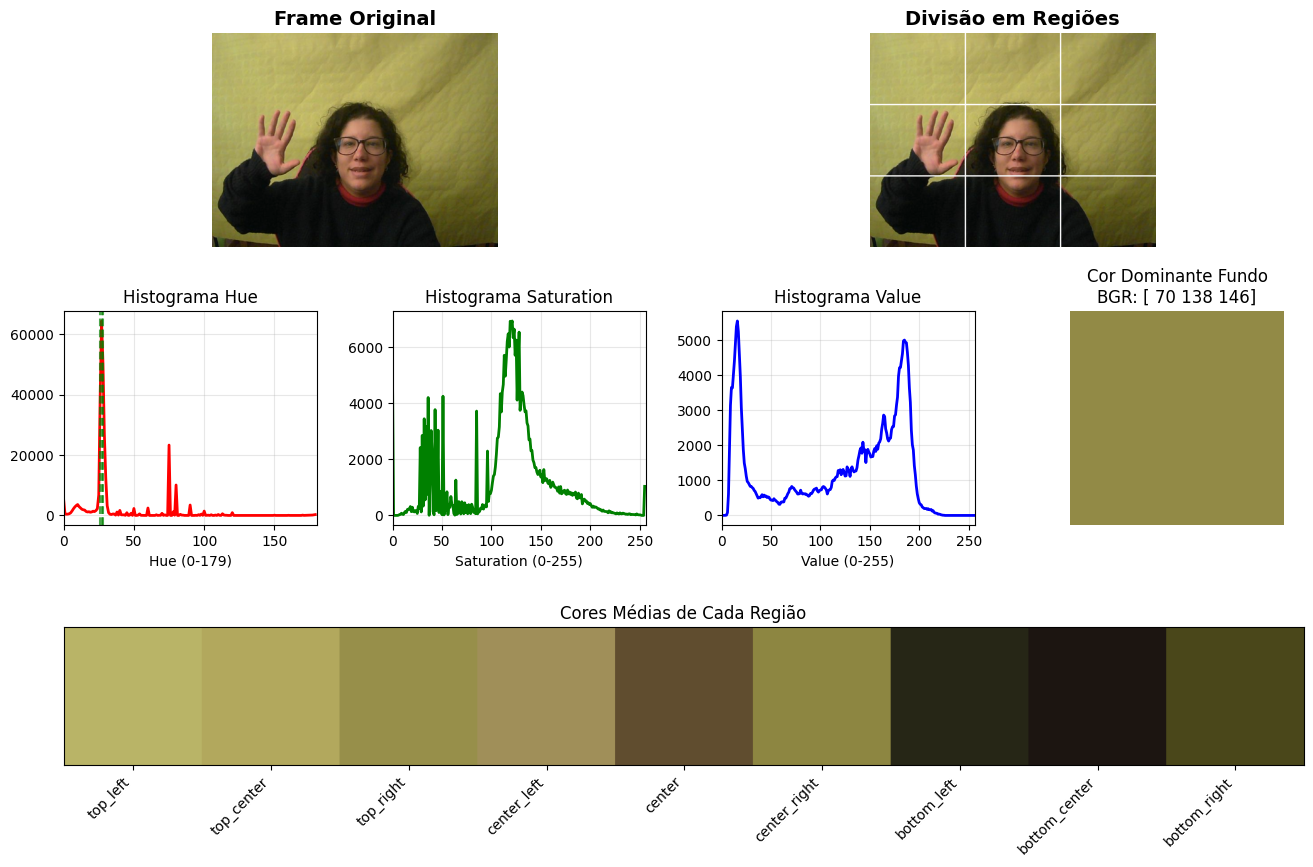


📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada
------------------------------------------------------------


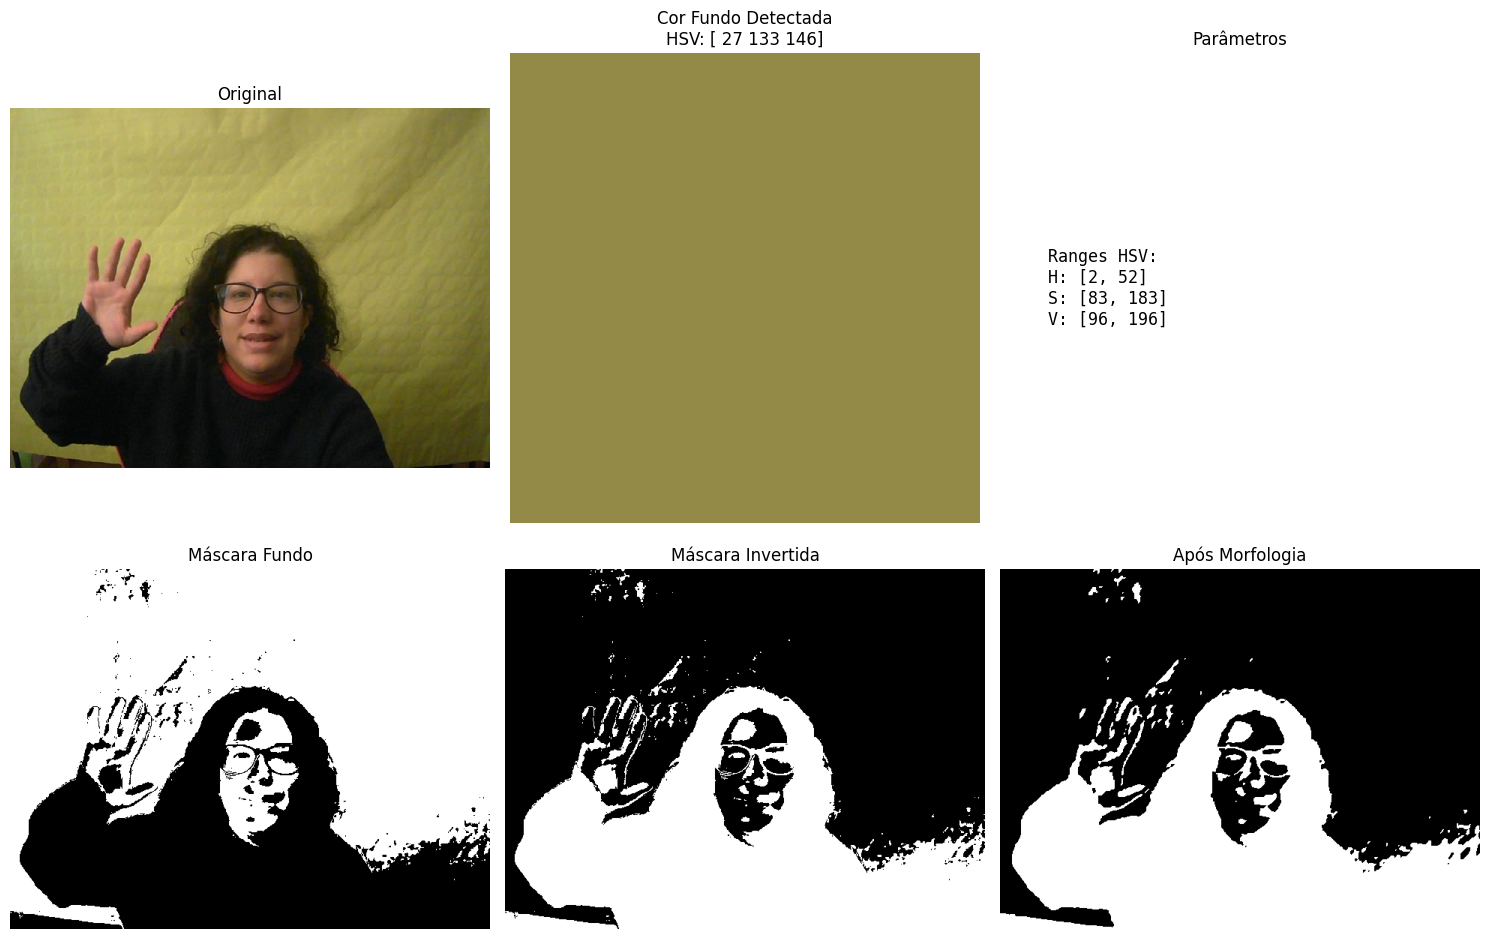


📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele
------------------------------------------------------------


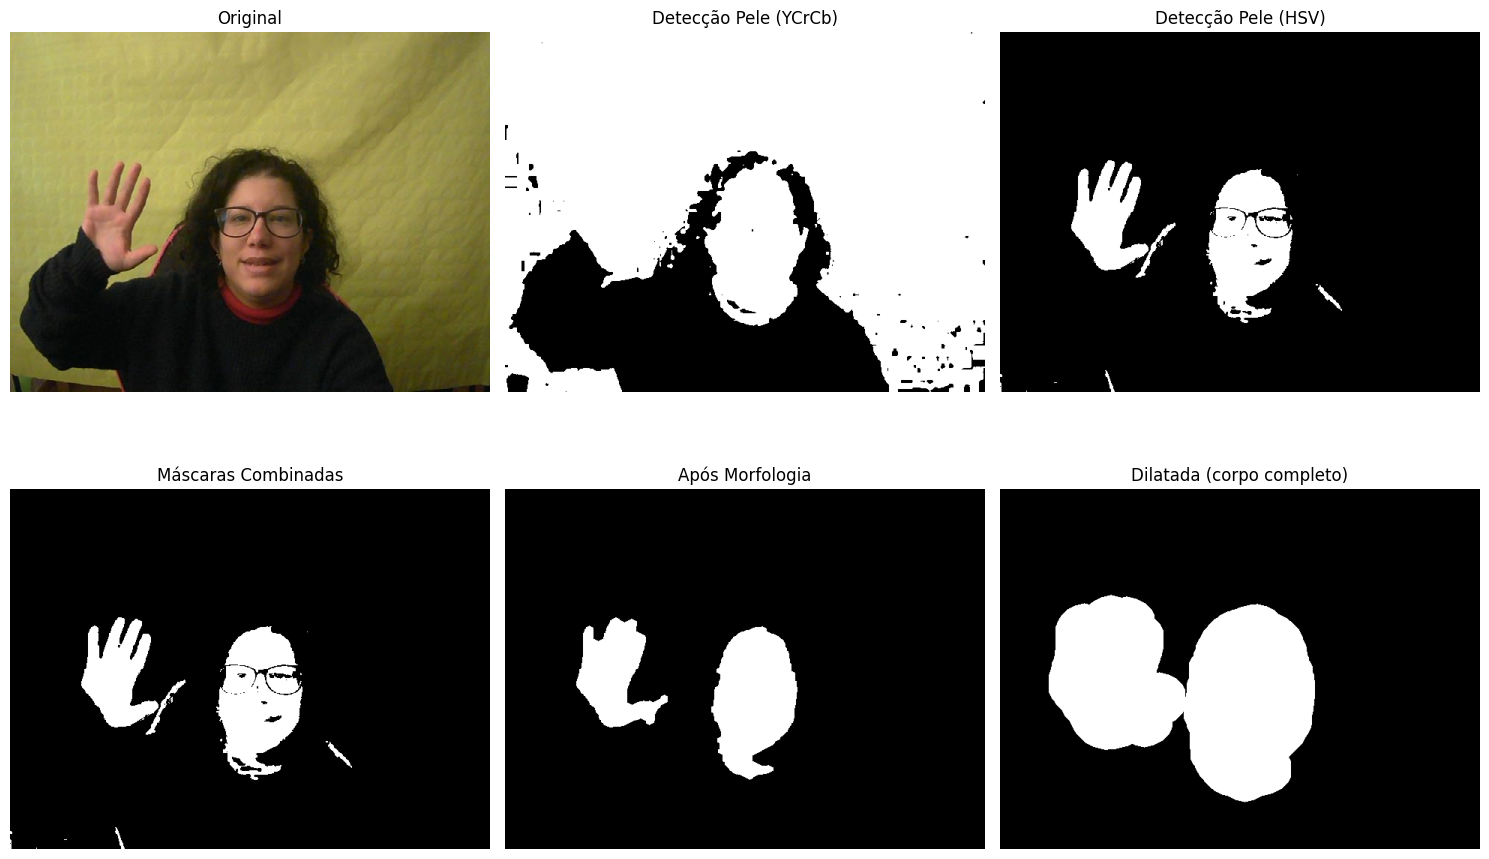


📊 EXPERIÊNCIA 4: Método Híbrido Inteligente
------------------------------------------------------------


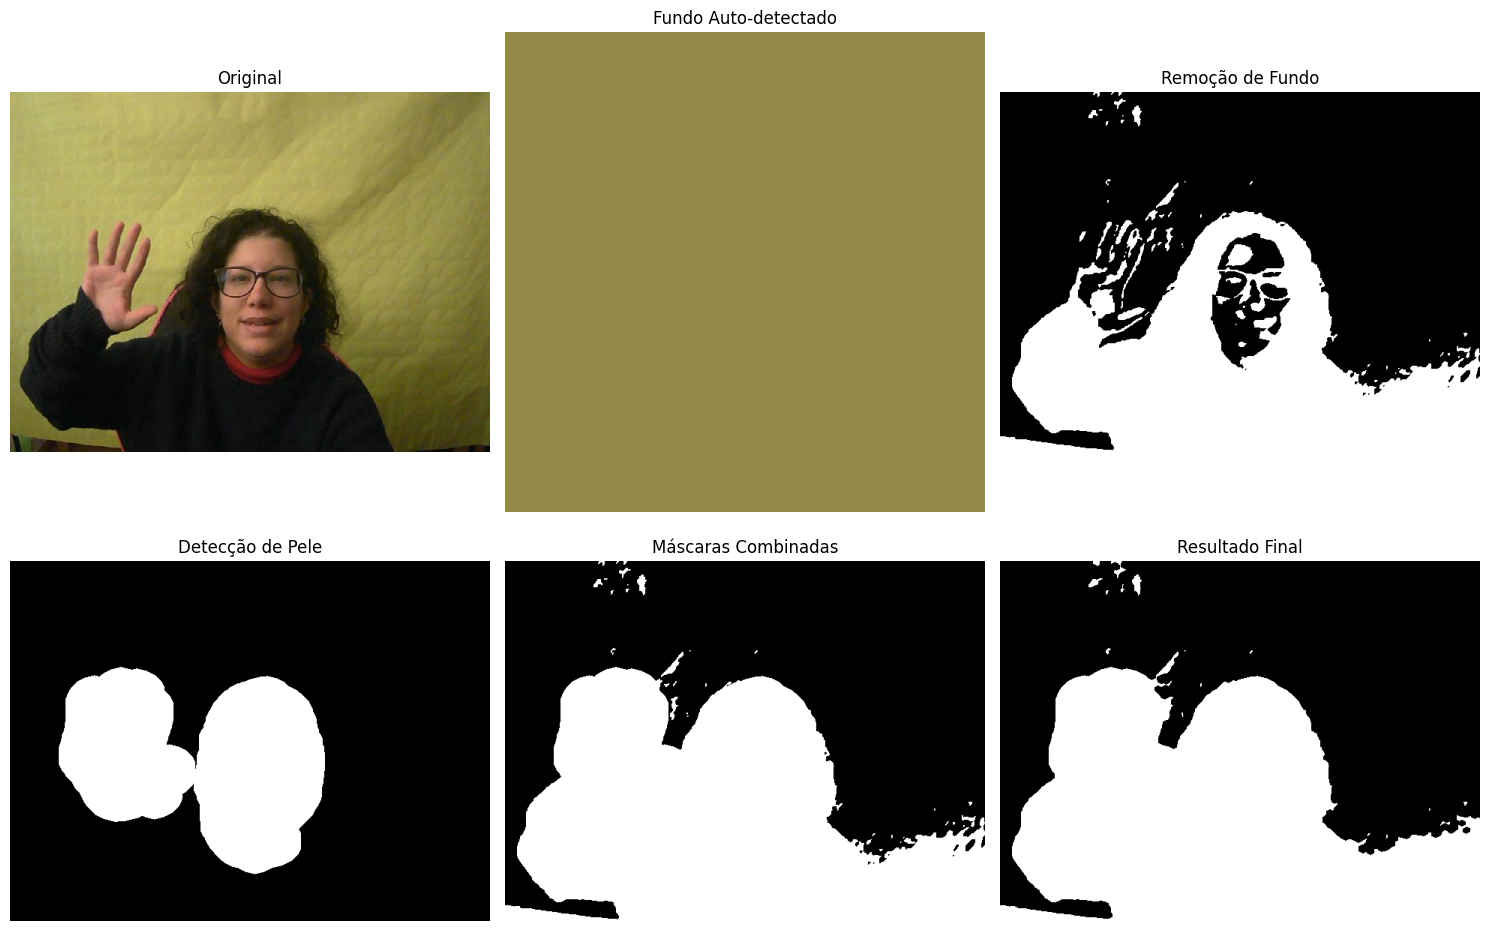


📈 ANÁLISE COMPARATIVA
Método 1 (Cor de Fundo): 36.1% detectado
Método 2 (Detecção Pele): 20.8% detectado
Método 3 (Híbrido):       45.9% detectado

💡 QUAL MÉTODO ESCOLHER?

Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!



In [21]:
# ==========================================
# TESTES PRÁTICOS
# ==========================================

print("="*60)
print("🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO")
print("="*60)

# Capturar frame
cap = cv.VideoCapture(0)
ret, frame_test = cap.read()

""" folder = "assets/media/"
frame_test = cv.imread(folder + "img_teste_3.png") """

if ret:
    frame_test = cv.flip(frame_test, 1)
    print("✅ Frame capturado\n")

print("📊 EXPERIÊNCIA 1: Análise de Cores do Frame")
print("-" * 60)
analysis = analyze_frame_colors(frame_test, show_analysis=True)

print("\n📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada")
print("-" * 60)
mask_method1 = segment_by_background_color(frame_test, 
                                           analysis['dominant_bg_color_bgr'],
                                           tolerance=50, show_steps=True)

print("\n📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele")
print("-" * 60)
mask_method2 = segment_by_skin_detection(frame_test, show_steps=True)

print("\n📊 EXPERIÊNCIA 4: Método Híbrido Inteligente")
print("-" * 60)
mask_final = segment_hybrid_intelligent(frame_test, show_steps=True)

cap.release()

# Comparação estatística
print("\n" + "="*60)
print("📈 ANÁLISE COMPARATIVA")
print("="*60)

total_pixels = mask_method1.shape[0] * mask_method1.shape[1]

perc1 = (np.sum(mask_method1 > 0) / total_pixels) * 100
perc2 = (np.sum(mask_method2 > 0) / total_pixels) * 100
perc3 = (np.sum(mask_final > 0) / total_pixels) * 100

print(f"Método 1 (Cor de Fundo): {perc1:.1f}% detectado")
print(f"Método 2 (Detecção Pele): {perc2:.1f}% detectado")
print(f"Método 3 (Híbrido):       {perc3:.1f}% detectado")

print("\n" + "="*60)
print("💡 QUAL MÉTODO ESCOLHER?")
print("="*60)
print("""
Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!
""")

### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>
